# Previsão de Temperatura Global com Machine Learning


Neste notebook, usamos dados históricos de temperatura média global para prever valores futuros (2024, 2044 e 2069) usando um modelo de Regressão Linear.


In [80]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, TheilSenRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
    

## Carregamento dos Dados e Preparação da Série Temporal

In [81]:

df = pd.read_csv("../data/Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding="ISO-8859-1")
df.columns = df.columns.str.replace("ï»¿", "")
df = df[df["Element"] == "Temperature change"]

df_long = df.melt(id_vars=["Area", "Months", "Element", "Unit"],
                  var_name="Year", value_name="Value")
df_long["Year"] = pd.to_numeric(df_long["Year"].str.extract(r"(\d+)")[0], errors="coerce")
df_long = df_long.dropna(subset=["Year"])
df_long["Year"] = df_long["Year"].astype(int)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")
df_long.dropna(subset=["Value"], inplace=True)
    

## Agrupar Dados Globais por Ano

In [82]:

df_global = df_long[df_long["Months"] == "Meteorological year"]
df_global = df_global.groupby("Year")["Value"].mean().reset_index()
df_global.head()
    

,Year,Value
0,1961,0.170922
1,1962,-0.022873
2,1963,-0.028361
3,1964,-0.106037
4,1965,-0.254930


## Treinamento do Modelo

In [83]:
# Features e alvo
X = df_global[["Year"]]
y = df_global["Value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos a testar
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "Polynomial (deg=2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Huber": HuberRegressor(),
    "TheilSen": TheilSenRegressor()
}

# Treinar e avaliar os modelos
print("Resultados de RMSE:")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, preds))
    print(f"{name}: RMSE = {rmse:.4f}")
    

Resultados de RMSE:
LinearRegression: RMSE = 0.2123
Ridge: RMSE = 0.2123
Lasso: RMSE = 0.2089
ElasticNet: RMSE = 0.2105
Polynomial (deg=2): RMSE = 0.1580
Huber: RMSE = 0.2126
TheilSen: RMSE = 0.2717


## Previsões Futuras para 2024, 2044 e 2069

In [84]:
best_model = models["Polynomial (deg=2)"]

anos_futuros = pd.DataFrame({"Year": [2024, 2034, 2044, 2059, 2069, 2100]})
previsoes = best_model.predict(anos_futuros)

for ano, temp in zip(anos_futuros["Year"], previsoes):
    print(f"Previsão para {ano}: {temp:.2f} °C")


Previsão para 2024: 1.63 °C
Previsão para 2034: 2.13 °C
Previsão para 2044: 2.69 °C
Previsão para 2059: 3.64 °C
Previsão para 2069: 4.34 °C
Previsão para 2100: 6.90 °C


## Visualização da Tendência e Previsões

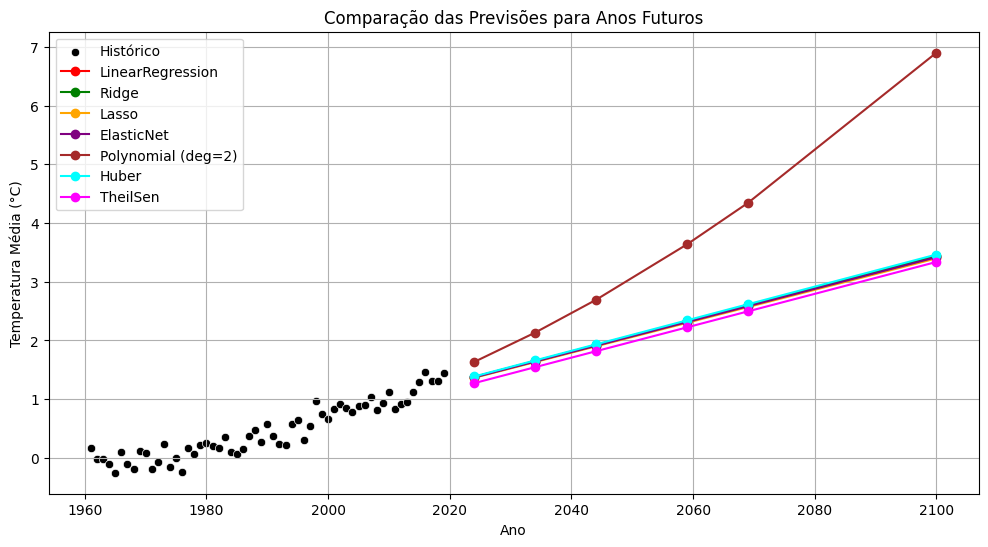

In [85]:
anos_futuros = pd.DataFrame({"Year": [2024, 2034, 2044, 2059, 2069, 2100]})

plt.figure(figsize=(12, 6))
sns.scatterplot(x="Year", y="Value", data=df_global, label="Histórico", color='black')

cores = ['red', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']
for (name, model), cor in zip(models.items(), cores):
    preds_futuros = model.predict(anos_futuros)
    plt.plot(anos_futuros["Year"], preds_futuros, label=name, color=cor, marker='o')

plt.title("Comparação das Previsões para Anos Futuros")
plt.xlabel("Ano")
plt.ylabel("Temperatura Média (°C)")
plt.legend()
plt.grid(True)
plt.show()


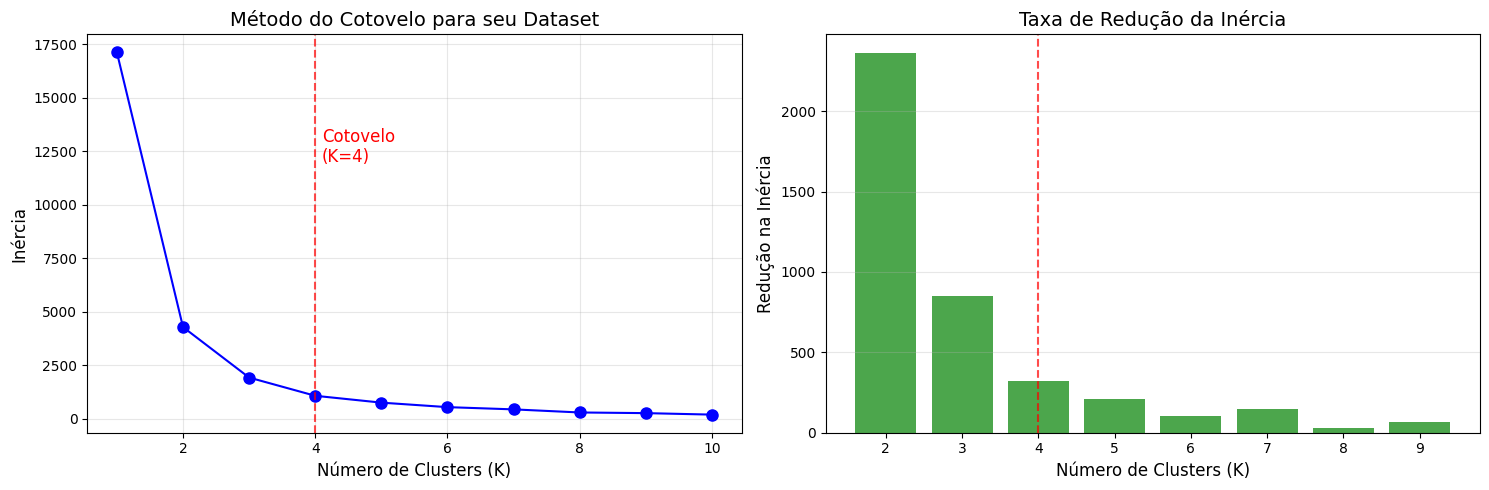

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dados para clustering
X = df_global[["Year", "Value"]].values

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Calcula a taxa de mudança (segunda derivada aproximada)
deltas = np.diff(inertias)
deltas2 = np.diff(deltas)

# Plotagem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico do método do cotovelo
ax1.plot(K_range, inertias, 'bo-', markersize=8)
# Tentativa automática para achar o cotovelo aproximado (pode ajustar manualmente)
cotovelo = 4
ax1.axvline(x=cotovelo, color='red', linestyle='--', alpha=0.7)
ax1.set_xlabel('Número de Clusters (K)', fontsize=12)
ax1.set_ylabel('Inércia', fontsize=12)
ax1.set_title('Método do Cotovelo para seu Dataset', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.text(cotovelo + 0.1, max(inertias)*0.7, f'Cotovelo\n(K={cotovelo})', fontsize=12, color='red')

# Gráfico da taxa de redução da inércia
ax2.bar(range(2, 10), -deltas[1:], alpha=0.7, color='green')
ax2.set_xlabel('Número de Clusters (K)', fontsize=12)
ax2.set_ylabel('Redução na Inércia', fontsize=12)
ax2.set_title('Taxa de Redução da Inércia', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')
ax2.axvline(x=cotovelo, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



## Clustering KMenas


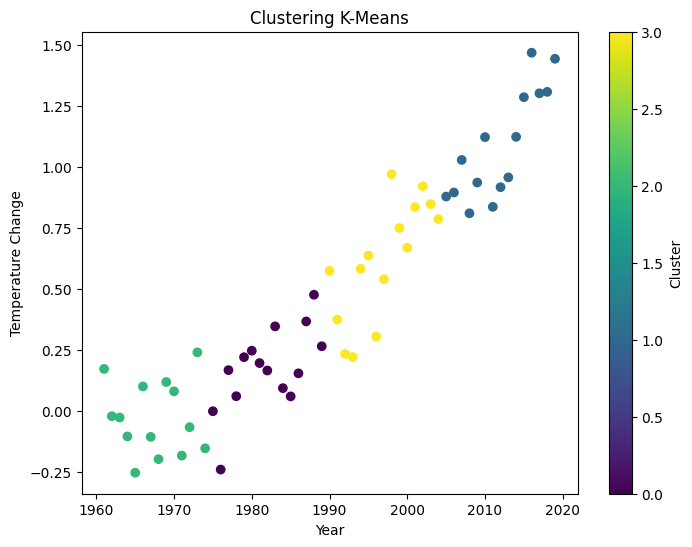

Silhouette Score: 0.5428


In [87]:
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Dados para clustering (exemplo: ano e valor da temperatura)
X = df_global[["Year", "Value"]]

# Defina número de clusters desejados, por exemplo 3
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Resultados: rótulos dos clusters para cada ponto
labels = kmeans.labels_

# Visualizando clusters
plt.figure(figsize=(8,6))
plt.scatter(X["Year"], X["Value"], c=labels, cmap='viridis')
plt.xlabel("Year")
plt.ylabel("Temperature Change")
plt.title("Clustering K-Means")
plt.colorbar(label="Cluster")
plt.show()


silhouette = silhouette_score(X, labels)
print(f"Silhouette Score: {silhouette:.4f}")



## Previsão por Áreas

In [88]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

anos_futuros = np.array([2024, 2034, 2044, 2059, 2069, 2100]).reshape(-1, 1)

# Lista para armazenar resultados
lista_resultados = []

# Lista de todas as áreas únicas
areas = df_long["Area"].unique()

for area in areas:
    df_area = df_long[(df_long["Area"] == area) & (df_long["Months"] == "Meteorological year")].dropna(subset=["Value"])

    # Precisa ter dados suficientes para treinar
    if len(df_area) < 10:
        continue  # pula áreas com poucos dados
    
    X = df_area[["Year"]]
    y = df_area["Value"]
    
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # Previsão para os anos futuros
    X_futuro_poly = poly.transform(anos_futuros)
    preds_futuro = model.predict(X_futuro_poly)
    
    # Guardar resultados
    for ano, pred in zip(anos_futuros.flatten(), preds_futuro):
        lista_resultados.append({"Area": area, "Year": ano, "Predicted_Temperature": pred})

# Criar DataFrame com previsões
df_previsoes = pd.DataFrame(lista_resultados)

print(df_previsoes.head())

# Opcional: salvar para CSV
# df_previsoes.to_csv("previsoes_temperatura_areas.csv", index=False)


C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-package

          Area  Year  Predicted_Temperature
0  Afghanistan  2024               1.599635
1  Afghanistan  2034               2.114254
2  Afghanistan  2044               2.694090
3  Afghanistan  2059               3.686127
4  Afghanistan  2069               4.429007


C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
C:\Users\Gabriel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-package

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_22684\730683284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x="Predicted_Temperature", y="Area", palette="magma")


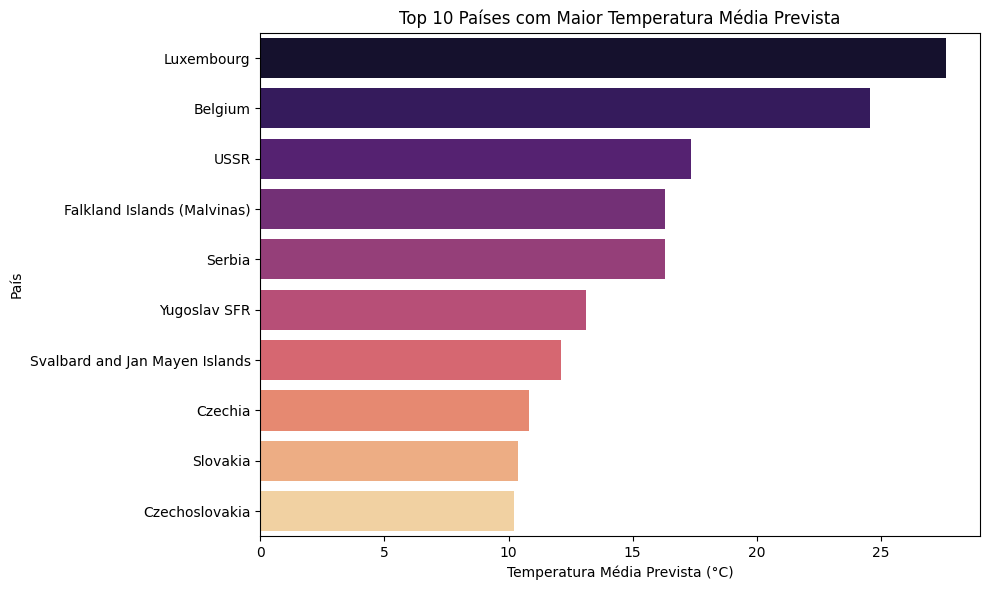

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por Área e calcular média da temperatura prevista
media_por_area = df_previsoes.groupby("Area")["Predicted_Temperature"].mean().reset_index()

# Ordenar do maior para o menor
media_por_area = media_por_area.sort_values(by="Predicted_Temperature", ascending=False)

# Selecionar os 10 maiores
top_10 = media_por_area.head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x="Predicted_Temperature", y="Area", palette="magma")

plt.title("Top 10 Países com Maior Temperatura Média Prevista")
plt.xlabel("Temperatura Média Prevista (°C)")
plt.ylabel("País")
plt.tight_layout()
plt.show()


C:\Users\Gabriel\AppData\Local\Temp\ipykernel_22684\2888630163.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_10, x="Predicted_Temperature", y="Area", palette="coolwarm")


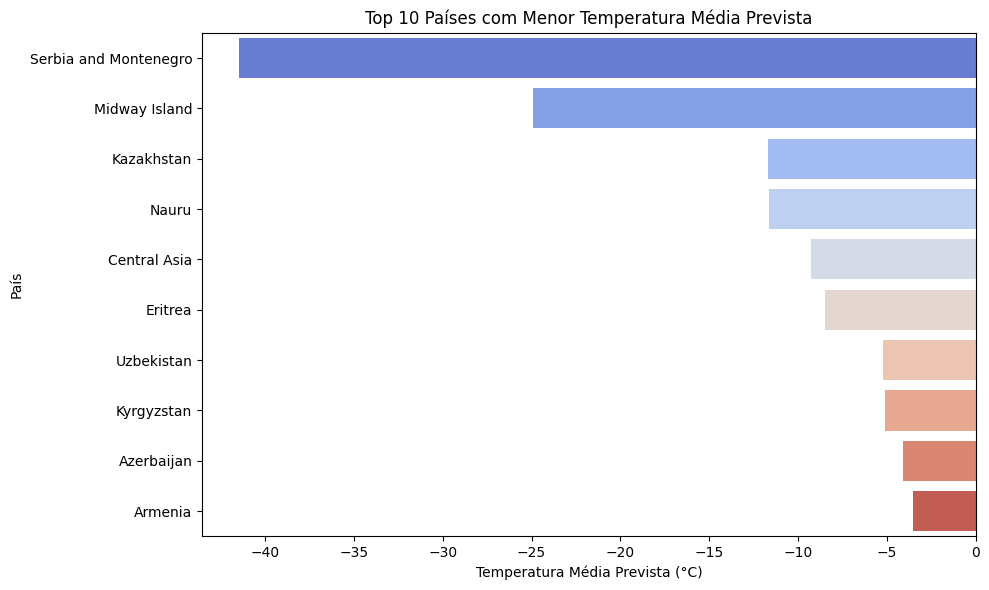

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupar por Área e calcular média da temperatura prevista
media_por_area = df_previsoes.groupby("Area")["Predicted_Temperature"].mean().reset_index()

# Ordenar do menor para o maior
media_por_area = media_por_area.sort_values(by="Predicted_Temperature", ascending=True)

# Selecionar os 10 menores
bottom_10 = media_por_area.head(10)

# Plotar gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_10, x="Predicted_Temperature", y="Area", palette="coolwarm")

plt.title("Top 10 Países com Menor Temperatura Média Prevista")
plt.xlabel("Temperatura Média Prevista (°C)")
plt.ylabel("País")
plt.tight_layout()
plt.show()
